[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/studiobuilders/ism-cyberrag/blob/main/notebooks/sprint1_poc.ipynb)

# ISM-CyberRAG — Sprint 1 POC

**Baseline RAG pipeline** for the Australian Information Security Manual.

Pipeline: Parse ISM PDFs → Chunk → Embed → Store in Supabase pgvector → Retrieve → Generate Answer (Groq) → Evaluate (RAGAS) → Log (ClearML)


---

**Team Name:** Studio Builders

**Team Members:**

- Sreekar Reddy Edulapalli (25617806)
- Chandan Sreenivasaiah (25674250)
- Ruben Easo Thomas (25598184)


---
## 1 · Environment Setup

In [1]:
# ── Set up the environment, clone repository, and install necessary dependencies ──
import os
import sys

# ── Clone repo if running in Colab / SageMaker ──
if not os.path.exists('ism-cyberrag') and not os.path.exists('../src'):
    !git clone -q https://github.com/studiobuilders/ism-cyberrag.git
    %cd ism-cyberrag

# ── Find project root and make src importable ──
cwd = os.getcwd()
if 'notebooks' in cwd:
    project_root = os.path.abspath('..')
else:
    project_root = cwd

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ── Install dependencies ──
req_path = os.path.join(project_root, 'requirements.txt')
!pip install -qr {req_path}

print(f'Project root: {project_root}')
print('Environment ready.')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Project root: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag
Environment ready.


---
## 2 · ClearML Initialization

ClearML reads credentials from environment variables automatically (`CLEARML_API_ACCESS_KEY`, `CLEARML_API_SECRET_KEY`, `CLEARML_API_HOST`, `CLEARML_WEB_HOST`, `CLEARML_FILES_HOST`). Set these in your `.env` file.

In [2]:
# ── Initialize ClearML to track data processing experiments ──
from src.config import CLEARML_PROJECT, CLEARML_TASK
from clearml import Task
from datetime import datetime

# Add a dynamic timestamp to ensure every run is logged as a separate experiment
dynamic_task_name = f"{CLEARML_TASK} [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]"

task = Task.init(
    project_name=CLEARML_PROJECT,
    task_name=dynamic_task_name,
    task_type=Task.TaskTypes.data_processing,
    reuse_last_task_id=False,  # Force a clean, new task every time
)
print(f'ClearML task created: {CLEARML_PROJECT} / {dynamic_task_name}')
print(f'View at: https://app.clear.ml')

ClearML Task: created new task id=e657b1ea94804d8fadd1694fd5140e12


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/8cc0565844234597add9563254af0f2e/experiments/e657b1ea94804d8fadd1694fd5140e12/output/log
ClearML task created: ISM-CyberRAG / Sprint 1 – Baseline RAG [2026-03-22 14:00:59]
View at: https://app.clear.ml


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


---
## 3 · Initialize Clients & Models

In [3]:
# ── Initialize Supabase database client and load embedding models ──
from src.config import (
    EMBEDDING_MODEL_NAME, EMBEDDING_DIMENSION,
    CHUNK_SIZE, CHUNK_OVERLAP, MATCH_COUNT,
    DATA_DIR, EVAL_DIR, EVAL_DATASET_PATH,
)
from src.supabase_utils import get_supabase_client, count_rows
from src.embeddings import load_embedding_model

# ── Supabase ──
supabase = get_supabase_client()
print(f'Supabase client ready.')
print(f'  Existing chunks in DB: {count_rows(supabase, "chunks")}')

# ── Embedding Model ──
embedding_model = load_embedding_model()
print(f'Embedding model loaded: {EMBEDDING_MODEL_NAME} ({EMBEDDING_DIMENSION}-dim)')

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/venv/lib/python3.13/site-packages/clearml/binding/import_bind.py:64: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = builtins.__org_import__(name, globals=globals, locals=locals, fromlist=fromlist, level=level)


Supabase client ready.
  Existing chunks in DB: 900


<All keys matched successfully>


Embedding model loaded: nomic-ai/nomic-embed-text-v1.5 (768-dim)


---
## 4 · Data Ingestion Pipeline

Parse all 25 ISM PDFs → chunk → embed → store in Supabase pgvector.

> ⚠️ **Run this section once** to populate the database. Skip to Section 5 if data is already ingested.

### 4.1 · Parse PDFs

In [ ]:
# ── Parse the contents of all ISM PDF documents into text ──
from src.parse_pdf import parse_all_pdfs

documents = parse_all_pdfs(DATA_DIR)
print(f'\nTotal characters: {sum(len(d["text"]) for d in documents):,}')

### 4.2 · Chunk Documents

In [ ]:
# ── Split the parsed documents into processable overlapping chunks ──
from src.chunking import chunk_text

all_chunks = []
for doc in documents:
    chunks = chunk_text(doc['text'], chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
    for chunk in chunks:
        all_chunks.append({
            'content': chunk,
            'metadata': {
                'source_file': doc['source_file'],
                'title': doc['title'],
            },
        })

print(f'Total chunks: {len(all_chunks)}')
print(f'Config: chunk_size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP}')

### 4.3 · Generate Embeddings

In [ ]:
# ── Generate vector embeddings for every chunk ──
from src.embeddings import embed_texts

texts = [c['content'] for c in all_chunks]
embeddings = embed_texts(embedding_model, texts)

print(f'Generated {len(embeddings)} embeddings')
print(f'Embedding dimension: {len(embeddings[0])}')

### 4.4 · Store in Supabase pgvector

In [ ]:
# ── Store the generated chunks and their embeddings into Supabase pgvector in batches ──
from src.supabase_utils import insert_chunks

# Build rows for insertion
rows = []
for i, chunk_data in enumerate(all_chunks):
    rows.append({
        'content': chunk_data['content'],
        'embedding': embeddings[i],
        'metadata': chunk_data['metadata'],
    })

# Insert in batches
BATCH_SIZE = 50
for start in range(0, len(rows), BATCH_SIZE):
    batch = rows[start:start + BATCH_SIZE]
    insert_chunks(supabase, batch)
    print(f'  Batch {start // BATCH_SIZE + 1}: inserted {len(batch)} rows')

total = count_rows(supabase, 'chunks')
print(f'\nTotal rows in chunks table: {total}')

---
## 5 · Retrieval Demo

Test vector similarity search on a sample question.

In [4]:
# ── Perform a test vector similarity search with a sample question ──
from src.embeddings import embed_query
from src.retrieval import match_chunks

question = 'What does the ISM say about multi-factor authentication?'

query_emb = embed_query(embedding_model, question)
results = match_chunks(supabase, query_emb, match_count=MATCH_COUNT)

print(f'Question: {question}\n')
for i, r in enumerate(results, 1):
    sim = r.get('similarity', 0)
    print(f'--- Chunk {i} (similarity: {sim:.4f}) ---')
    print(r['content'][:300])
    print()

Question: What does the ISM say about multi-factor authentication?

--- Chunk 1 (similarity: 0.8581) ---
dated: Jun-24; Applicable: NC, OS, P, S, TS; Essential 8: N/A 
When multi-factor authentication is used to authenticate users or customers to online services or online 
customer services, all other authentication protocols that do not support multi-factor authentication are 
disabled. 
Control: ISM-

--- Chunk 2 (similarity: 0.8555) ---
authentication is used to authenticate users to their organisation’s online services that process, 
store or communicate their organisation’s sensitive data. 
Control: ISM-1679; Revision: 1; Updated: Sep-23; Applicable: NC, OS, P, S, TS; Essential 8: ML1, ML2, ML3 
Multi-factor authentication is use

--- Chunk 3 (similarity: 0.8535) ---
Essential 8: ML1, ML2, ML3 
Multi-factor authentication is used to authenticate users to their organisation’s online customer services 
that process, store or communicate their organisation’s sensitive customer data. 

---
## 6 · Answer Generation

Generate a cited answer using the configured Main LLM (configured in `src/config.py` or `.env`).

In [5]:
# ── Generate the final answer using the Groq LLM model ──
from src.llm import generate_answer

answer = generate_answer(question, results)

print(f'Question: {question}\n')
print(f'Answer:\n{answer}')

Question: What does the ISM say about multi-factor authentication?

Answer:
According to the provided context, the Australian Information Security Manual (ISM) states that multi-factor authentication is used to:

- Authenticate users or customers to online services or online customer services (ISM-1173, ISM-0974, ISM-1505, ISM-1919)
- Authenticate users to their organisation's online services that process, store or communicate their organisation's sensitive data (ISM-1679)
- Authenticate users to third-party online services that process, store or communicate their organisation's sensitive data (ISM-1679)
- Authenticate users to their organisation's online customer services that process, store or communicate their organisation's sensitive customer data (ISM-1892, ISM-1893, ISM-1681)
- Authenticate customers to online customer services that process, store or communicate sensitive customer data (ISM-1681)
- Authenticate users or customers to online services or online customer services, di

---
## 7 · Interactive Q&A Helper

Convenience function for end-to-end RAG.

In [6]:
# ── Interactive Q&A Helper function for end-to-end RAG testing ──
def ask_ism(question: str, top_k: int = MATCH_COUNT):
    """End-to-end: embed query → retrieve → generate answer."""
    q_emb = embed_query(embedding_model, question)
    chunks = match_chunks(supabase, q_emb, match_count=top_k)
    answer = generate_answer(question, chunks)
    return answer, chunks

# Test it
q = 'What does the ISM say about multi-factor access?'
ans, ctx = ask_ism(q)
print(f'Q: {q}\n')
print(f'A: {ans}')

Q: What does the ISM say about multi-factor access?

A: According to the context, the ISM does not explicitly mention "multi-factor access." However, it does discuss multi-factor authentication (ISM-1173, ISM-0974, ISM-1505, etc.) which involves using multiple factors to authenticate users or customers to online services or online customer services.


---
## 8 · RAGAS Evaluation

Evaluate the baseline pipeline using RAGAS metrics.

The evaluation LLM is configured independently via `EVAL_LLM_PROVIDER` and `EVAL_LLM_MODEL` in `.env`.

In [7]:
# ── Load the eval dataset to evaluate pipeline on 20 questions ──
import pandas as pd
from src.evaluation import load_eval_dataset, run_ragas_evaluation

eval_data = load_eval_dataset(EVAL_DATASET_PATH)
pd.DataFrame(eval_data)[['question', 'category']]

Loaded 40 evaluation questions.


,question,category
0,What are the six functions that group the cybe...,easy
1,What is the primary purpose of the Information...,easy
2,Who is the intended audience for the Informati...,easy
3,What types of checks does a vulnerability scan...,easy
4,How often must cyber security awareness traini...,easy
5,What is the ISM definition of a cyber security...,easy
6,What does the abbreviation AACA stand for?,easy
7,How frequently should a vulnerability scanner ...,easy
8,How long must event logs be retained in a sear...,easy
9,When are break glass accounts permitted to be ...,easy


In [8]:
# ── Run the RAG pipeline on all evaluation questions using retrieval and generation functions ──
# Define retrieve and generate functions for the evaluator
def retrieve_fn(question):
    q_emb = embed_query(embedding_model, question)
    return match_chunks(supabase, q_emb, match_count=MATCH_COUNT)

def generate_fn(question, chunks):
    return generate_answer(question, chunks)

# Run pipeline on all eval questions
print('Running RAG pipeline on evaluation dataset...\n')
eval_results = run_ragas_evaluation(eval_data, retrieve_fn, generate_fn)
print(f'\nCompleted {len(eval_results)} evaluations.')

Running RAG pipeline on evaluation dataset...

  [1/40] (0.49s) What are the six functions that group the cyber security pri...
  [2/40] (0.47s) What is the primary purpose of the Information security manu...
  [3/40] (0.46s) Who is the intended audience for the Information security ma...
  [4/40] (13.55s) What types of checks does a vulnerability scan perform?...
  [5/40] (13.49s) How often must cyber security awareness training be undertak...
  [6/40] (13.45s) What is the ISM definition of a cyber security incident?...
  [7/40] (13.73s) What does the abbreviation AACA stand for?...
  [8/40] (14.49s) How frequently should a vulnerability scanner be used to ide...
  [9/40] (14.48s) How long must event logs be retained in a searchable manner?...
  [10/40] (12.45s) When are break glass accounts permitted to be used?...
  [11/40] (15.52s) What is the minimum password length for single-factor authen...
  [12/40] (13.75s) What action should be taken if IT equipment cannot be saniti...
  [13

In [9]:
# ── Compute RAGAS scores and build per-question results DataFrame ──

from src.evaluation import compute_ragas_scores

ragas_metrics, ragas_df = compute_ragas_scores(eval_results)


/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:117: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  eval_llm = ChatOllama(
/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:133: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  eval_embeddings = HuggingFaceEmbeddings(


Using Ollama as RAGAS judge (model: llama3.1:8b)


<All keys matched successfully>


Computing RAGAS metrics (sequential, max_retries=3)...


Evaluating: 100%|██████████| 160/160 [36:53<00:00, 13.84s/it]



══════ RAGAS Evaluation Results ══════
  faithfulness              0.7037
  answer_relevancy          0.7406
  context_precision         0.8284
  context_recall            0.7938
  avg_retrieval_time_s      0.3210
  avg_generation_time_s     12.7822
  avg_total_time_s          13.1032


In [10]:
# ── Display per-question RAGAS scores and latency metrics ──
import pandas as pd

# Select columns to display (exclude raw contexts for readability)
display_cols = [c for c in ragas_df.columns if c != 'contexts']
pd.set_option('display.max_colwidth', 80)
ragas_df[display_cols]

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall,retrieval_time_s,generation_time_s,total_time_s
0,What are the six functions that group the cyber security principles within t...,"[ideration of such issues. When designing, operating and decommissioning sys...",The six functions that group the cyber security principles within the ISM ar...,"The cyber security principles are grouped into six functions: govern, identi...",1.000000,1.000000,0.887500,1.000000,0.3057,0.1822,0.4879
1,What is the primary purpose of the Information security manual (ISM)?,[1 \nInformation security manual \nUsing the Information security manual \n ...,The primary purpose of the Information security manual (ISM) is to outline a...,The purpose of the Information security manual (ISM) is to outline a cyber s...,1.000000,1.000000,0.950000,0.800000,0.2874,0.1850,0.4724
2,Who is the intended audience for the Information security manual?,[1 \nInformation security manual \nUsing the Information security manual \n ...,The intended audience for the Information security manual (ISM) is chief inf...,"The ISM is intended for chief information security officers (CISOs), chief i...",1.000000,0.935275,0.755556,1.000000,0.2813,0.1819,0.4632
3,What types of checks does a vulnerability scan perform?,[ulnerability scan involves using tools to conduct automated checks for know...,A vulnerability scan involves using tools to conduct automated checks for kn...,A vulnerability scan involves using tools to conduct automated checks for kn...,1.000000,0.888294,1.000000,1.000000,0.3603,13.1903,13.5505
4,How often must cyber security awareness training be undertaken by personnel?,[1 \nInformation security manual \nGuidelines for personnel security \n \nLa...,"According to Chunk 1 and Chunk 2, cyber security awareness training is under...",Cyber security awareness training is undertaken annually by all personnel.,1.000000,0.984889,1.000000,1.000000,0.2844,13.2012,13.4856
5,What is the ISM definition of a cyber security incident?,"[security incident An unwanted or unexpected cyber security event, or a seri...","A cyber security incident is an unwanted or unexpected cyber security event,...","A cyber security incident is an unwanted or unexpected cyber security event,...",1.000000,0.887356,1.000000,0.857143,0.2478,13.2004,13.4482
6,What does the abbreviation AACA stand for?,[1 \nInformation security manual \nCyber security terminology \n \nLast upda...,AACA stands for ASD-Approved Cryptographic Algorithm.,AACA stands for ASD-Approved Cryptographic Algorithm.,1.000000,0.962398,1.000000,1.000000,0.5497,13.1801,13.7299
7,How frequently should a vulnerability scanner be used to identify missing pa...,[scanning should be conducted in an automated manner and take place at twice...,ISM-1701 states that a vulnerability scanner is used at least daily to ident...,A vulnerability scanner is used at least daily to identify missing patches o...,1.000000,0.687764,0.755556,1.000000,0.2737,14.2124,14.4861
8,How long must event logs be retained in a searchable manner?,[searchable manner for at least 12 months. \nControl: ISM-1989; Revision: 0;...,"According to the context, event logs must be retained in a searchable manner...",Event logs are retained in a searchable manner for at least 12 months.,0.666667,1.000000,1.000000,1.000000,0.2889,14.1959,14.4848
9,When are break glass accounts permitted to be used?,"[a method for gaining access during emergencies. Typically, emergencies \nca...",Break glass accounts are only used when normal authentication processes cann...,Break glass accounts are only used when normal authentication processes cann...,0.500000,0.904191,1.000000,1.000000,0.2574,12.1965,12.4538


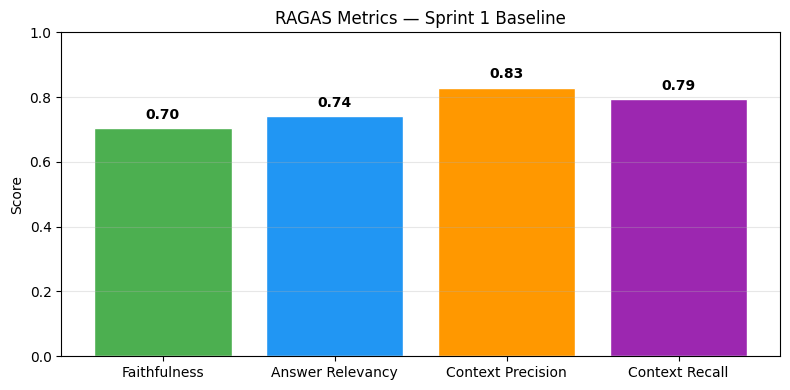

In [13]:
# ── Visualise RAGAS metric scores as a bar chart ──
import matplotlib.pyplot as plt

metric_names = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
scores = [ragas_metrics.get(m, 0) for m in metric_names]
labels = [m.replace('_', ' ').title() for m in metric_names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'], edgecolor='white')
ax.set_ylabel('Score')
ax.set_title('RAGAS Metrics — Sprint 1 Baseline')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 8.2 · Latency Metrics

In [14]:
# ── Display latency summary statistics ──
latency_cols = ['retrieval_time_s', 'generation_time_s', 'total_time_s']
available_cols = [c for c in latency_cols if c in ragas_df.columns]

if available_cols:
    latency_stats = ragas_df[available_cols].describe().round(4)
    print('Latency Statistics (seconds):')
    print(latency_stats.to_string())
else:
    print('No latency data available.')

Latency Statistics (seconds):
       retrieval_time_s  generation_time_s  total_time_s
count           40.0000            40.0000       40.0000
mean             0.3210            12.7822       13.1032
std              0.0953             3.7660        3.7703
min              0.2478             0.1819        0.4632
25%              0.2711            13.1914       13.4837
50%              0.2859            13.3179       13.7100
75%              0.3160            14.2657       14.5794
max              0.6966            16.2885       16.5596


---
## 9 · Log Results to ClearML

In [15]:
# ── Log evaluation metrics, parameters, results, and sample Q&A to ClearML ──
from src.config import LLM_MODEL_NAME, LLM_PROVIDER, EVAL_LLM_PROVIDER, EVAL_LLM_MODEL
from src.evaluation import log_metrics_to_clearml

# Extract numeric metrics only
numeric_metrics = {k: v for k, v in ragas_metrics.items() if isinstance(v, (int, float))}

log_metrics_to_clearml(
    metrics=numeric_metrics,
    params={
        'chunking_strategy': 'fixed_size',
        'chunk_size': CHUNK_SIZE,
        'chunk_overlap': CHUNK_OVERLAP,
        'embedding_model': EMBEDDING_MODEL_NAME,
        'embedding_dimension': EMBEDDING_DIMENSION,
        'llm_provider': LLM_PROVIDER,
        'llm_model': LLM_MODEL_NAME,
        'eval_llm_provider': EVAL_LLM_PROVIDER,
        'eval_llm_model': EVAL_LLM_MODEL,
        'retrieval_method': 'vector_similarity',
        'match_count': MATCH_COUNT,
        'num_eval_questions': len(eval_data),
        'num_chunks_in_db': count_rows(supabase, 'chunks'),
    },
    results_df=ragas_df,
    eval_results=eval_results,
)

print('All metrics, parameters, and results logged to ClearML.')

✓ Uploaded eval_results artifact (40 rows).
✓ Logged 10 sample Q&A outputs to ClearML.
✓ Logged 7 metrics to ClearML.
All metrics, parameters, and results logged to ClearML.


---
## 10 · Close ClearML Task

In [16]:
# ── Terminate and mark the current ClearML tracking task as completed ──
from clearml import Task

# Get the currently running task and close it
current_task = Task.current_task()
if current_task:
    current_task.close()
    print("✓ ClearML task successfully closed and marked as 'Completed'.")
else:
    print("No active ClearML task found.")

✓ ClearML task successfully closed and marked as 'Completed'.
